# PSL Autonomous Driving — Interactive Exploration

Walks through the stack layer by layer:
1. Environment wrapper + raw observation
2. Objective functions (safety / speed / comfort)
3. Policy and critic networks
4. Rollout collection
5. Mini A2C training loop with live plots

In [15]:
# [PSL-01] Setup: imports, sys.path, warnings
import sys, warnings
sys.path.insert(0, ".")
warnings.filterwarnings("ignore")  # suppress pygame pkg_resources deprecation

import numpy as np
import torch
import yaml
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

%matplotlib inline
plt.rcParams["figure.dpi"] = 110

## 1 · Environment Wrapper

In [16]:
# [PSL-02] Env wrapper: reset, obs shape
from envs import MOHighwayEnv

env = MOHighwayEnv()
obs, info = env.reset(seed=42)

print("observation shape :", obs.shape)          # (5, 5)
print("observation dtype :", obs.dtype)
print("reward_space      :", env.reward_space)
print()
print("Observation matrix (5 vehicles × [presence, x, y, vx, vy]):")
print(obs)

observation shape : (5, 5)
observation dtype : float32
reward_space      : Box(0.0, 1.0, (3,), float32)

Observation matrix (5 vehicles × [presence, x, y, vx, vy]):
[[ 1.          0.894922    0.          0.3125      0.        ]
 [ 1.          0.11214782  0.75       -0.01780258  0.        ]
 [ 1.          0.2252721   0.5        -0.02145726  0.        ]
 [ 1.          0.32675534  0.75       -0.03311053  0.        ]
 [ 1.          0.43310103  0.75       -0.01914644  0.        ]]


In [17]:
# [PSL-03] Env wrapper: single step, cost vector
# Take one step with a fixed action to see what the wrapper returns
action = 1  # IDLE
obs2, cost_vec, terminated, truncated, info2 = env.step(action)

print("cost_vec (safety, speed, comfort):", cost_vec)
print("per-objective breakdown          :", info2["objectives"])
print("terminated:", terminated, "  truncated:", truncated)

cost_vec (safety, speed, comfort): [0.00982287 0.16666667 0.        ]
per-objective breakdown          : {'f_safety': 0.009822866661436365, 'f_speed': 0.16666666666666666, 'f_comfort': 0.0}
terminated: False   truncated: False


## 2 · Objective Functions

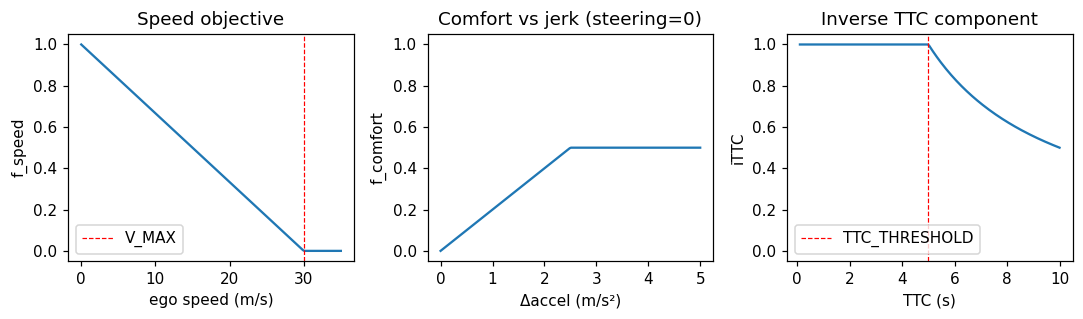

In [18]:
# [PSL-04] Objective functions: unit tests
from envs.objectives import compute_safety, compute_speed, compute_comfort

# --- f_speed: linear deviation from V_MAX = 30 m/s ---
speeds = np.linspace(0, 35, 200)
f_speeds = [compute_speed(v) for v in speeds]

plt.figure(figsize=(10, 3))
plt.subplot(1, 3, 1)
plt.plot(speeds, f_speeds)
plt.axvline(30, color="r", ls="--", lw=0.8, label="V_MAX")
plt.xlabel("ego speed (m/s)"); plt.ylabel("f_speed"); plt.title("Speed objective")
plt.legend(); plt.ylim(-0.05, 1.05)

# --- f_comfort: jerk component vs Δacceleration ---
dt = 0.5  # policy_frequency = 2 Hz
delta_a = np.linspace(0, 5, 200)   # m/s²
jerks = [compute_comfort(da, 0.0, 0.0, 20.0, dt) for da in delta_a]

plt.subplot(1, 3, 2)
plt.plot(delta_a, jerks)
plt.xlabel("Δaccel (m/s²)"); plt.ylabel("f_comfort"); plt.title("Comfort vs jerk (steering=0)")
plt.ylim(-0.05, 1.05)

# --- iTTC component: TTC_THRESHOLD / TTC ---
ttcs = np.linspace(0.1, 10, 200)
ittcs = np.clip(5.0 / ttcs, 0, 1)

plt.subplot(1, 3, 3)
plt.plot(ttcs, ittcs)
plt.axvline(5, color="r", ls="--", lw=0.8, label="TTC_THRESHOLD")
plt.xlabel("TTC (s)"); plt.ylabel("iTTC"); plt.title("Inverse TTC component")
plt.legend(); plt.ylim(-0.05, 1.05)

plt.tight_layout()
plt.show()

## 3 · Policy and Critic Networks

In [19]:
# [PSL-05] Model architecture: policy + critic
from models.policy import ConditionedPolicy
from models.critic import VectorCritic

with open("configs/default.yaml") as f:
    config = yaml.safe_load(f)

pc = config["policy"]

policy = ConditionedPolicy(
    obs_dim=pc["obs_dim"],
    lam_dim=pc["lam_dim"],
    hidden_dim=pc["hidden_dim"],
    n_actions=pc["n_actions"],
)

critic = VectorCritic(
    obs_dim=pc["obs_dim"],
    lam_dim=pc["lam_dim"],
    hidden_dim=pc["hidden_dim"],
)

n_policy = sum(p.numel() for p in policy.parameters())
n_critic = sum(p.numel() for p in critic.parameters())
print(f"Policy parameters : {n_policy:,}")
print(f"Critic parameters : {n_critic:,}")
print()
print(policy)

Policy parameters : 21,268
Critic parameters : 21,004

ConditionedPolicy(
  (l1): Linear(in_features=28, out_features=128, bias=True)
  (l2): Linear(in_features=131, out_features=128, bias=True)
  (l3): Linear(in_features=131, out_features=5, bias=True)
)


In [20]:
# [PSL-06] Model forward pass test
# Test forward pass with a random observation and λ
obs_t = torch.tensor(obs.flatten(), dtype=torch.float32)
lam   = np.array([1/3, 1/3, 1/3])
lam_t = torch.tensor(lam, dtype=torch.float32)

logits = policy(obs_t, lam_t)
values = critic(obs_t, lam_t)

action, log_prob = policy.act(obs_t, lam_t)

action_names = ["LANE_LEFT", "IDLE", "LANE_RIGHT", "FASTER", "SLOWER"]

print("Logits :", logits.detach().numpy().round(3))
print("Probs  :", torch.softmax(logits, dim=-1).detach().numpy().round(3))
print(f"Sampled: {action_names[action]} (log_prob={log_prob.item():.3f})")
print()
print("Critic values [V_safety, V_speed, V_comfort]:", values.detach().numpy().round(4))

Logits : [ 0.333 -0.349 -0.063 -0.312  0.337]
Probs  : [0.27  0.136 0.182 0.142 0.271]
Sampled: LANE_LEFT (log_prob=-1.310)

Critic values [V_safety, V_speed, V_comfort]: [ 0.1249  0.1792 -0.4258]


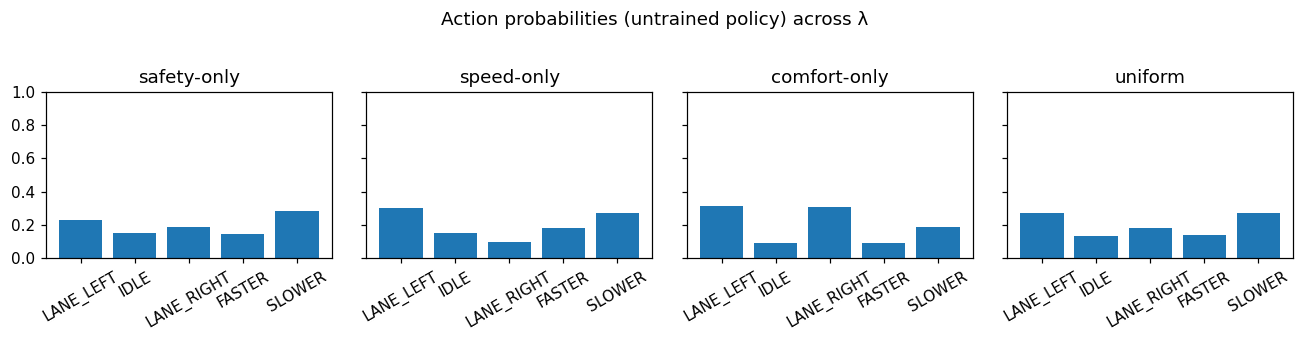

In [21]:
# [PSL-07] Action prob shift across λ
# Visualise how action probabilities shift across different λ preferences
lam_grid = [
    ("safety-only",  np.array([1.0, 0.0, 0.0])),
    ("speed-only",   np.array([0.0, 1.0, 0.0])),
    ("comfort-only", np.array([0.0, 0.0, 1.0])),
    ("uniform",      np.array([1/3, 1/3, 1/3])),
]

fig, axes = plt.subplots(1, len(lam_grid), figsize=(12, 3), sharey=True)
for ax, (label, lam_val) in zip(axes, lam_grid):
    lam_t_val = torch.tensor(lam_val, dtype=torch.float32)
    probs = torch.softmax(policy(obs_t, lam_t_val), dim=-1).detach().numpy()
    ax.bar(action_names, probs)
    ax.set_title(label)
    ax.set_ylim(0, 1)
    ax.tick_params(axis="x", rotation=30)
plt.suptitle("Action probabilities (untrained policy) across λ", y=1.02)
plt.tight_layout()
plt.show()

## 4 · Rollout Collection

In [22]:
# [PSL-08] Rollout collection
from training.rollout import collect_episode, episode_summary

lam = np.array([1/3, 1/3, 1/3])

returns, log_probs, values, entropies = collect_episode(
    env, policy, critic, lam, gamma=0.99
)

print(f"Episode length    : {len(returns)} steps")
print(f"returns shape     : {returns.shape}   (T x 3)")
print(f"log_probs shape   : {log_probs.shape}  (T,)")
print(f"values shape      : {values.shape}   (T x 3)")
print(f"entropies shape   : {entropies.shape} (T,)")
print()
summary = episode_summary(returns)
print("Episode summary:")
for k, v in summary.items():
    print(f"  {k:12s}: {v:.4f}")


Episode length    : 13 steps
returns shape     : torch.Size([13, 3])   (T x 3)
log_probs shape   : torch.Size([13])  (T,)
values shape      : torch.Size([13, 3])   (T x 3)
entropies shape   : torch.Size([13]) (T,)

Episode summary:
  G_safety    : 1.3497
  G_speed     : 3.3486
  G_comfort   : 6.2431
  G_total     : 10.9413
  length      : 13.0000


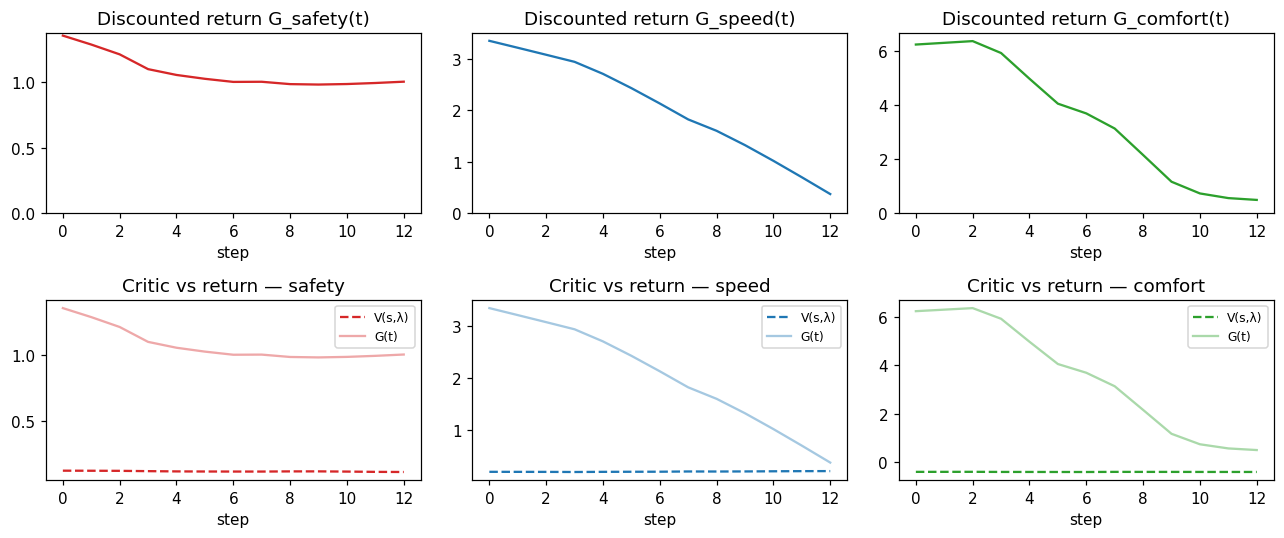

In [23]:
# [PSL-09] Per-step cost + return plots
# Plot per-step costs and discounted returns over the episode
T = returns.shape[0]
obj_labels = ["safety", "speed", "comfort"]
colors = ["tab:red", "tab:blue", "tab:green"]

fig, axes = plt.subplots(2, 3, figsize=(12, 5))

for i, (label, color) in enumerate(zip(obj_labels, colors)):
    ax = axes[0, i]
    ax.plot(returns[:, i].detach().numpy(), color=color)
    ax.set_title(f"Discounted return G_{label}(t)")
    ax.set_xlabel("step")
    ax.set_ylim(0, None)

    ax2 = axes[1, i]
    ax2.plot(values[:, i].detach().numpy(), color=color, ls="--", label="V(s,λ)")
    ax2.plot(returns[:, i].detach().numpy(), color=color, alpha=0.4, label="G(t)")
    ax2.set_title(f"Critic vs return — {label}")
    ax2.set_xlabel("step")
    ax2.legend(fontsize=8)

plt.tight_layout()
plt.show()

## 5 · Advantages

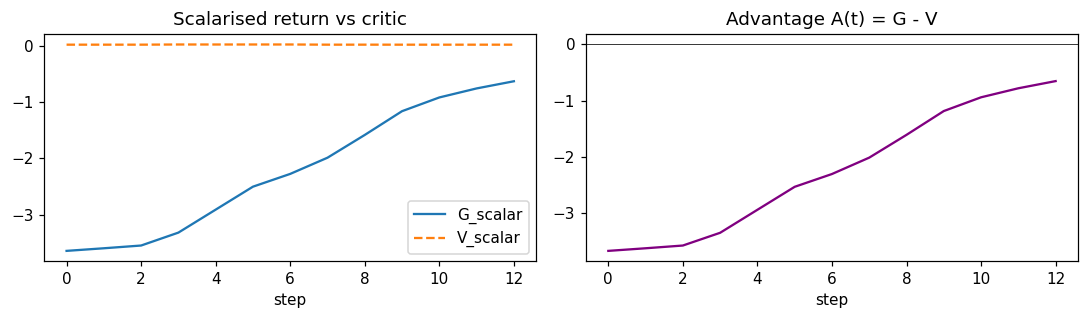

Advantage mean: -2.2452  std: 1.1365


In [24]:
# [PSL-10] Advantage computation
lam_t = torch.tensor(lam, dtype=torch.float32)

# Scalarise: negate costs → rewards, weight by λ
reward_returns = (-returns) @ lam_t   # (T,)
reward_values  = (-values)  @ lam_t   # (T,)
advantages     = (reward_returns - reward_values).detach()

plt.figure(figsize=(10, 3))
plt.subplot(1, 2, 1)
plt.plot(reward_returns.detach(), label="G_scalar")
plt.plot(reward_values.detach(),  label="V_scalar", ls="--")
plt.legend(); plt.xlabel("step"); plt.title("Scalarised return vs critic")

plt.subplot(1, 2, 2)
plt.plot(advantages, color="purple")
plt.axhline(0, color="k", lw=0.5)
plt.xlabel("step"); plt.title("Advantage A(t) = G - V")

plt.tight_layout()
plt.show()

print(f"Advantage mean: {advantages.mean().item():.4f}  std: {advantages.std().item():.4f}")

## 6 · Mini A2C Training Loop

50 episodes — enough to see the loss curve shape and verify the gradient flow.

In [25]:
# [PSL-11] Mini A2C training loop (50 eps, fixed λ)
tc = config["train"]

policy_fresh = ConditionedPolicy(
    obs_dim=pc["obs_dim"], lam_dim=pc["lam_dim"],
    hidden_dim=pc["hidden_dim"], n_actions=pc["n_actions"]
)
critic_fresh = VectorCritic(
    obs_dim=pc["obs_dim"], lam_dim=pc["lam_dim"], hidden_dim=pc["hidden_dim"]
)

opt_policy = torch.optim.Adam(policy_fresh.parameters(), lr=tc["learning_rate"])
opt_critic  = torch.optim.Adam(critic_fresh.parameters(), lr=tc["critic_lr"])

lam    = np.array([1/3, 1/3, 1/3])
lam_t  = torch.tensor(lam, dtype=torch.float32)
GAMMA         = tc["gamma"]
ENTROPY_COEF  = tc.get("entropy_coef", 0.01)
N_EPISODES    = 50

history = {"policy_loss": [], "critic_loss": [], "G_safety": [], "G_speed": [], "G_comfort": []}

env2 = MOHighwayEnv(config=config.get("env", {}))
for ep in range(1, N_EPISODES + 1):
    ret, lps, vals, ents = collect_episode(env2, policy_fresh, critic_fresh, lam, gamma=GAMMA)

    # costs: lower is better. scalar advantage = lambda . (G - V)
    scalar_ret  = (ret  @ lam_t)          # (T,)
    scalar_vals = (vals @ lam_t)           # (T,)
    adv = (scalar_ret - scalar_vals).detach()

    policy_loss = (adv * lps).mean() - ENTROPY_COEF * ents.mean()
    critic_loss = ((ret.detach() - vals) ** 2).mean()

    opt_policy.zero_grad()
    policy_loss.backward()
    torch.nn.utils.clip_grad_norm_(policy_fresh.parameters(), 0.5)
    opt_policy.step()

    opt_critic.zero_grad()
    critic_loss.backward()
    torch.nn.utils.clip_grad_norm_(critic_fresh.parameters(), 0.5)
    opt_critic.step()

    s = episode_summary(ret)
    history["policy_loss"].append(policy_loss.item())
    history["critic_loss"].append(critic_loss.item())
    history["G_safety"].append(s["G_safety"])
    history["G_speed"].append(s["G_speed"])
    history["G_comfort"].append(s["G_comfort"])

    if ep % 20 == 0:
        print(f"ep {ep:3d} | policy_loss={policy_loss.item():+.4f} | "
              f"critic_loss={critic_loss.item():.4f} | "
              f"G=[{s["G_safety"]:.3f}, {s["G_speed"]:.3f}, {s["G_comfort"]:.3f}]")

env2.close()


ep  20 | policy_loss=+0.0953 | critic_loss=0.8860 | G=[4.043, 0.430, 3.210]
ep  40 | policy_loss=+0.2184 | critic_loss=0.9744 | G=[3.562, 2.215, 4.474]


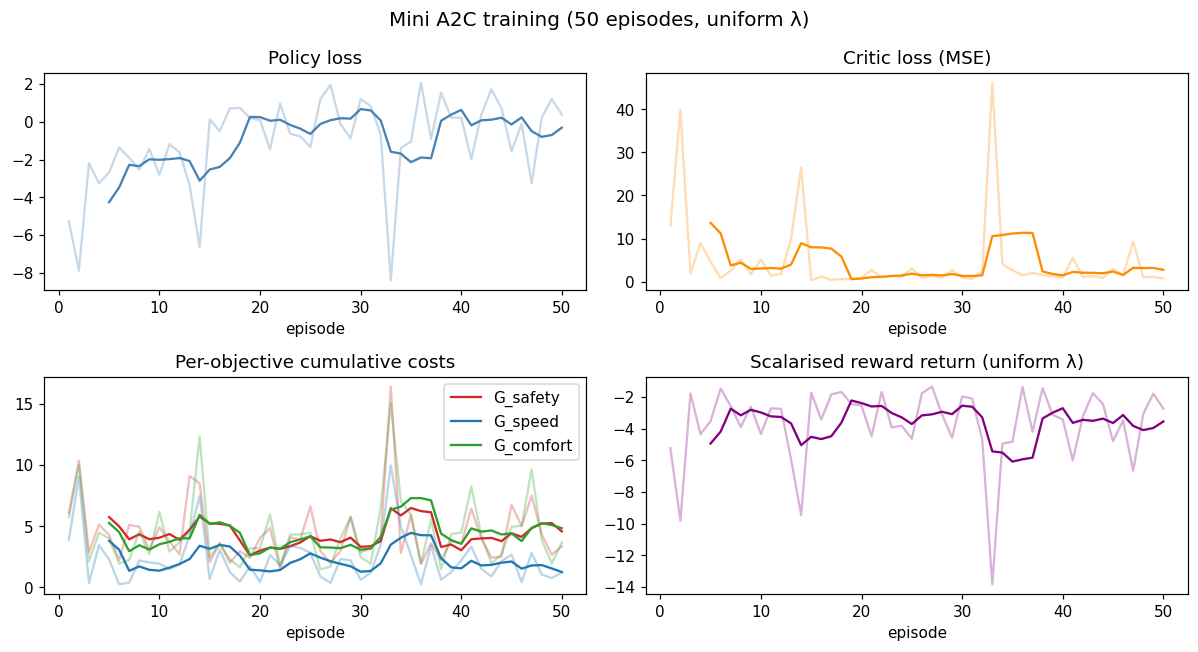

In [26]:
# [PSL-12] Mini A2C loss + G curves
def smooth(x, w=5):
    return np.convolve(x, np.ones(w)/w, mode="valid")

eps = np.arange(1, N_EPISODES + 1)

fig, axes = plt.subplots(2, 2, figsize=(11, 6))

axes[0,0].plot(eps, history["policy_loss"], alpha=0.3, color="steelblue")
axes[0,0].plot(eps[4:], smooth(history["policy_loss"]), color="steelblue")
axes[0,0].set_title("Policy loss"); axes[0,0].set_xlabel("episode")

axes[0,1].plot(eps, history["critic_loss"], alpha=0.3, color="darkorange")
axes[0,1].plot(eps[4:], smooth(history["critic_loss"]), color="darkorange")
axes[0,1].set_title("Critic loss (MSE)"); axes[0,1].set_xlabel("episode")

for label, color in [("G_safety", "tab:red"), ("G_speed", "tab:blue"), ("G_comfort", "tab:green")]:
    axes[1,0].plot(eps, history[label], alpha=0.3, color=color)
    axes[1,0].plot(eps[4:], smooth(history[label]), color=color, label=label)
axes[1,0].set_title("Per-objective cumulative costs"); axes[1,0].set_xlabel("episode")
axes[1,0].legend()

# Scalarised return
g_scalar = -(np.array(history["G_safety"]) + np.array(history["G_speed"]) + np.array(history["G_comfort"])) / 3
axes[1,1].plot(eps, g_scalar, alpha=0.3, color="purple")
axes[1,1].plot(eps[4:], smooth(g_scalar), color="purple")
axes[1,1].set_title("Scalarised reward return (uniform λ)")
axes[1,1].set_xlabel("episode")

plt.suptitle(f"Mini A2C training ({N_EPISODES} episodes, uniform λ)", fontsize=13)
plt.tight_layout()
plt.show()

## 7 · Pareto Set Learning (PSL) with LibMOON

Sections 1–6 verified the RL loop on a *fixed* preference. Now we use **LibMOON's EPO solver** to train a single network that handles *all* preferences. After training, we'll show the same network producing different driving styles by changing only the input λ — no retraining.

### 7.1 · Smoke-test the LibMOON EPO solver

EPO (Exact Pareto Optimal) takes a Jacobian J ∈ ℝ³ˣⁿ (one row per objective gradient) and a current loss vector, then returns mixing weights α ∈ ℝ³ that produce a Pareto-stationary descent direction matching the target preference.

In [27]:
# [PSL-13] EPO smoke test (synthetic Jacobians)
from libmoon.solver.gradient.methods.epo_solver import EPOCore

# Build a synthetic 3-objective problem with n_var=10 parameters
torch.manual_seed(0)
J_synthetic = torch.randn(3, 10)            # gradients per objective
losses_synthetic = torch.tensor([0.6, 0.3, 0.1])   # current per-objective losses
obj_labels = ['safety', 'speed', 'comfort']

prefs_to_test = [
    np.array([0.7, 0.2, 0.1]),   # safety-leaning
    np.array([0.1, 0.7, 0.2]),   # speed-leaning
    np.array([0.1, 0.2, 0.7]),   # comfort-leaning
    np.array([1/3, 1/3, 1/3]),   # uniform
]

print('─' * 72)
print('EPO decision logic: v/λ ratio per objective')
print('  v/λ < 1  →  objective is OVER-achieved relative to preference ray')
print('  v/λ = 1  →  objective is ON the preference ray')
print('  v/λ > 1  →  objective is UNDER-achieved; EPO focuses here')
print('─' * 72)
print(f"Fixed losses: safety={losses_synthetic[0]:.1f}  speed={losses_synthetic[1]:.1f}  comfort={losses_synthetic[2]:.1f}")
print()

for p in prefs_to_test:
    ratios = losses_synthetic.numpy() / p
    worst  = int(np.argmax(ratios))

    p_t   = torch.tensor(p, dtype=torch.float32).unsqueeze(0)
    core  = EPOCore(n_var=10, prefs=p_t)
    alpha = core.get_alpha(J_synthetic, losses_synthetic, idx=0).numpy()
    g_combined = alpha @ J_synthetic.numpy()

    pref_str = f'[{", ".join(f"{x:.2f}" for x in p)}]'
    print(f'pref={pref_str}')
    for i, lab in enumerate(obj_labels):
        marker = ' ← highest v/λ (EPO focuses here)' if i == worst else ''
        print(f'  {lab:8s}: λ={p[i]:.2f}  v={losses_synthetic[i]:.1f}  v/λ={ratios[i]:.3f}{marker}')
    print(f'  α = {alpha.round(3)}  (focus on {obj_labels[worst]})'
          f'   ||g||={np.linalg.norm(g_combined):.3f}')
    print()

print('─' * 72)
print('Key: α ≠ λ. EPO does not follow the preference directly.')
print('     It corrects toward the Pareto front at the λ-ray by focusing')
print('     on whichever objective is most above its ray position (highest v/λ).')
print('     Only near the Pareto front does α converge toward λ.')


────────────────────────────────────────────────────────────────────────
EPO decision logic: v/λ ratio per objective
  v/λ < 1  →  objective is OVER-achieved relative to preference ray
  v/λ = 1  →  objective is ON the preference ray
  v/λ > 1  →  objective is UNDER-achieved; EPO focuses here
────────────────────────────────────────────────────────────────────────
Fixed losses: safety=0.6  speed=0.3  comfort=0.1

pref=[0.70, 0.20, 0.10]
  safety  : λ=0.70  v=0.6  v/λ=0.857
  speed   : λ=0.20  v=0.3  v/λ=1.500 ← highest v/λ (EPO focuses here)
  comfort : λ=0.10  v=0.1  v/λ=1.000
  α = [0. 1. 0.]  (focus on speed)   ||g||=1.574

pref=[0.10, 0.70, 0.20]
  safety  : λ=0.10  v=0.6  v/λ=6.000 ← highest v/λ (EPO focuses here)
  speed   : λ=0.70  v=0.3  v/λ=0.429
  comfort : λ=0.20  v=0.1  v/λ=0.500
  α = [1. 0. 0.]  (focus on safety)   ||g||=3.212

pref=[0.10, 0.20, 0.70]
  safety  : λ=0.10  v=0.6  v/λ=6.000 ← highest v/λ (EPO focuses here)
  speed   : λ=0.20  v=0.3  v/λ=1.500
  comfort : λ=0

**What to look for:** For each preference, the table shows `v/λ` — the ratio of current
objective cost to preference weight. EPO focuses the gradient on whichever objective has
the **highest v/λ**, i.e. whose cost is most disproportionate relative to its preference
weight. This is the objective furthest above the *preference ray*.

**α ≠ λ — this is intentional.** Linear scalarization sets α = λ and directly follows the
preference. EPO instead asks: *given the current policy's performance, which gradient
direction moves fastest toward the Pareto-optimal point for this λ?* That direction can
be orthogonal to λ. For example, a safety-heavy preference (λ = [0.7, 0.2, 0.1]) against
losses = [0.6, 0.3, 0.1] produces α = [0, 1, 0] — focus on speed — because speed's
v/λ ratio (0.3/0.2 = 1.5) is the highest, meaning it is the most out of proportion on the
preference ray, even though you barely care about it.

**Implication for training:** EPO only follows preferences closely once the policy is near
the Pareto front. Early in training (when costs are far from optimal) EPO always corrects
toward the front first, acting like min-max optimisation. This is why α is non-trivial
to interpret from the training curves alone.

### 7.2 · Run PSL training

Each PSL update samples K preference vectors from the Dirichlet, runs N episodes per preference, builds 3 per-objective gradient vectors via separate backward passes, and uses EPO to merge them.

We use a small budget here for notebook responsiveness. Increase `n_updates` for production runs.

In [28]:
# [PSL-14] PSL config + full training run
from training.psl_trainer import PSLTrainer, PSLConfig
import os

psl_cfg = PSLConfig(
    n_pref_samples=12,         # K — matches n_workers (one per physical core)
    n_episodes_per_pref=10,    # N — raised from 6; cleaner Jacobians for EPO LP.
    n_updates=150,             # raised from 100 — more updates for EPO to converge.
    gamma=0.99,
    learning_rate=3e-4,
    critic_lr=1e-3,
    entropy_coef=0.05,         # raised from 0.01 — keeps FASTER/SLOWER in distribution.
    p_corner=0.4,              # bumped from 0.25 — pair with deep lambda injection for stronger conditioning
    grad_clip=0.5,
    log_interval=5,
    save_interval=10,
    checkpoint_dir="checkpoints/psl",
    seed=42,
    n_workers=11,              # 11 of 12 physical cores (leave 1 for OS + main process)
)

trainer = PSLTrainer(psl_cfg, env_config=config.get("env", {}), policy_config=config.get("policy", {}))
print(f"Policy n_var = {trainer.n_var:,}")
print(f"Episodes per update = {psl_cfg.n_pref_samples * psl_cfg.n_episodes_per_pref}  "
      f"(running {psl_cfg.n_workers} preferences in parallel)")
print(f"Total episodes = {psl_cfg.n_pref_samples * psl_cfg.n_episodes_per_pref * psl_cfg.n_updates:,}")
print()

trainer.train()


Policy n_var = 21,268
Episodes per update = 120  (running 11 preferences in parallel)
Total episodes = 18,000

PSL upd   5/150  G=[s=0.512 v=0.119 c=0.412]  α=[0.58 0.08 0.33]  L_pol=[-2.980 -0.214 -1.662]  L_crit=3.9044
PSL upd  10/150  G=[s=0.515 v=0.111 c=0.417]  α=[0.62 0.08 0.30]  L_pol=[-1.231 +0.200 -0.552]  L_crit=1.8411
PSL upd  15/150  G=[s=0.526 v=0.103 c=0.432]  α=[0.29 0.32 0.40]  L_pol=[-0.171 +0.182 -0.134]  L_crit=2.2014
PSL upd  20/150  G=[s=0.524 v=0.114 c=0.435]  α=[0.33 0.00 0.67]  L_pol=[+0.500 -0.085 +0.182]  L_crit=1.9571
PSL upd  25/150  G=[s=0.512 v=0.125 c=0.383]  α=[0.47 0.00 0.53]  L_pol=[+0.046 +0.034 +0.023]  L_crit=1.7701
PSL upd  30/150  G=[s=0.510 v=0.119 c=0.426]  α=[0.33 0.08 0.58]  L_pol=[-0.420 -0.141 -0.630]  L_crit=2.5493
PSL upd  35/150  G=[s=0.510 v=0.124 c=0.415]  α=[0.42 0.08 0.50]  L_pol=[-0.001 -0.149 +0.155]  L_crit=1.5642
PSL upd  40/150  G=[s=0.512 v=0.127 c=0.437]  α=[0.50 0.17 0.33]  L_pol=[+0.071 -0.130 -0.252]  L_crit=1.6336
PSL upd  

### 7.3 · Visualise the EPO mixing weights and per-objective costs

Each update produces a per-batch mean of the EPO α weights. As training proceeds, α concentrates on whichever objective is currently the bottleneck — a sign that EPO is steering toward the Pareto frontier rather than getting pulled by any single preference.

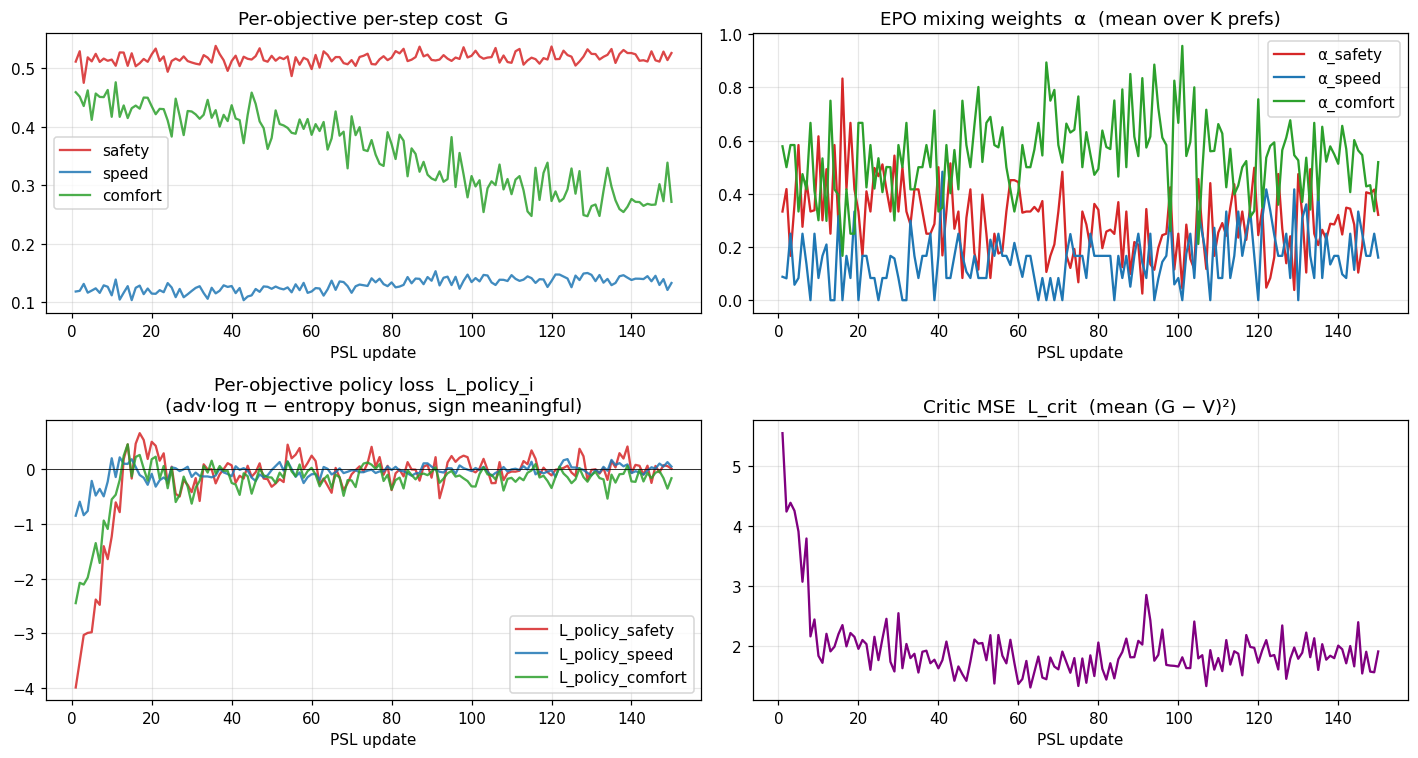

In [31]:
# [PSL-15] Training curves: G, α, L_policy, L_critic
import matplotlib.pyplot as plt

hist = trainer.history
steps = np.array(hist.update)
alpha_arr = np.stack(hist.alpha_mean)        # (n_updates, 3)

fig, axes = plt.subplots(2, 2, figsize=(13, 7))

# Per-objective costs (env-level)
for label, color, key in [
    ("safety",  "tab:red",   hist.G_safety),
    ("speed",   "tab:blue",  hist.G_speed),
    ("comfort", "tab:green", hist.G_comfort),
]:
    axes[0, 0].plot(steps, key, color=color, label=label, alpha=0.85)
axes[0, 0].set_title("Per-objective per-step cost  G")
axes[0, 0].set_xlabel("PSL update"); axes[0, 0].legend(); axes[0, 0].grid(alpha=0.3)

# EPO α weights
for i, (lab, color) in enumerate(zip(["α_safety", "α_speed", "α_comfort"],
                                     ["tab:red", "tab:blue", "tab:green"])):
    axes[0, 1].plot(steps, alpha_arr[:, i], color=color, label=lab)
axes[0, 1].set_title("EPO mixing weights  α  (mean over K prefs)")
axes[0, 1].set_xlabel("PSL update"); axes[0, 1].legend(); axes[0, 1].grid(alpha=0.3)

# Per-objective policy losses
for label, color, key in [
    ("L_policy_safety",  "tab:red",   hist.L_policy_safety),
    ("L_policy_speed",   "tab:blue",  hist.L_policy_speed),
    ("L_policy_comfort", "tab:green", hist.L_policy_comfort),
]:
    axes[1, 0].plot(steps, key, color=color, label=label, alpha=0.85)
axes[1, 0].axhline(0, color="k", lw=0.5)
axes[1, 0].set_title("Per-objective policy loss  L_policy_i\n(adv·log π − entropy bonus, sign meaningful)")
axes[1, 0].set_xlabel("PSL update"); axes[1, 0].legend(); axes[1, 0].grid(alpha=0.3)

# Critic loss — now the actual MSE
axes[1, 1].plot(steps, hist.L_critic, color="purple")
axes[1, 1].set_title("Critic MSE  L_crit  (mean (G − V)²)")
axes[1, 1].set_xlabel("PSL update"); axes[1, 1].grid(alpha=0.3)

plt.tight_layout(); plt.show()

### 7.4 · Diagnostic — does the policy actually condition on λ?

The four-row eval in section 8 only tells us about *outcomes*. If those rows look identical, we still don't know whether the policy's **action distribution** changed across λ or whether the env happened to produce similar costs.

This cell feeds the **same observations** through the trained policy under three corner-λ values and compares the resulting action distributions directly. If the bars look identical and TV distances are near 0, the network has collapsed onto a single λ-independent policy and no amount of further training will produce a real Pareto set without architectural changes.

Collected 8 diverse observations for the diagnostic.



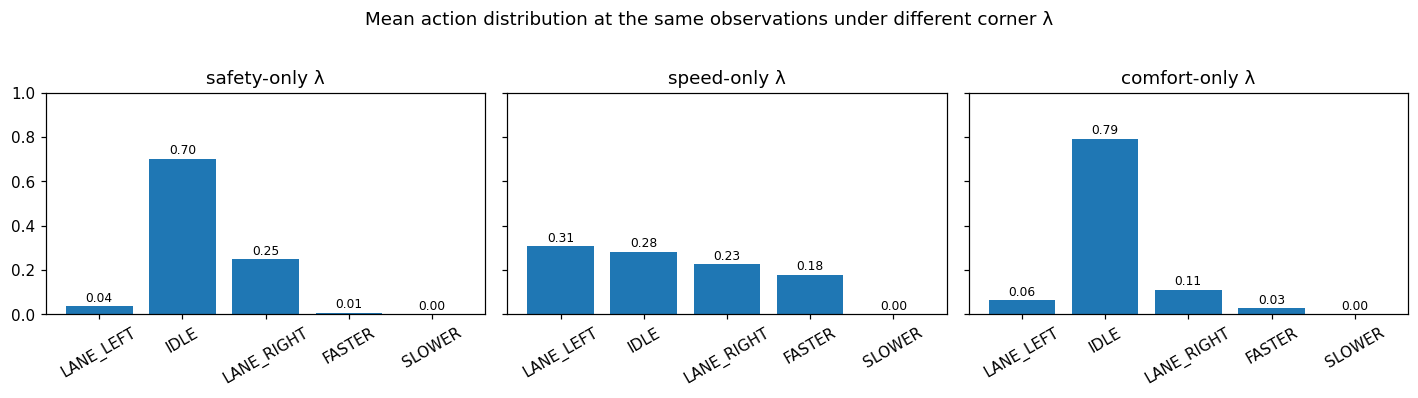

Pairwise total-variation distance between corner-λ distributions
(0 = identical → policy ignores λ;  larger = stronger conditioning)

  safety-only λ       vs  speed-only λ        →  TV = 0.445   (ok — meaningful λ response)
  safety-only λ       vs  comfort-only λ      →  TV = 0.139   (weak conditioning)
  speed-only λ        vs  comfort-only λ      →  TV = 0.510   (ok — meaningful λ response)

Mean pairwise TV distance: 0.365
→ Conditioning is working. Section 8 results should reflect real λ-driven adaptation.


In [32]:
# [PSL-16] λ-conditioning diagnostic: TV distance
import torch.nn.functional as F
from itertools import combinations

trained_policy = trainer.policy
trained_policy.eval()

# --- 1. Collect a small bank of diverse observations ---
diag_env = MOHighwayEnv(config=config.get("env", {}))
obs_bank = []
o, _ = diag_env.reset(seed=123)
obs_bank.append(o.flatten())
for _ in range(7):
    a = diag_env.action_space.sample()
    o, _, term, trunc, _ = diag_env.step(a)
    obs_bank.append(o.flatten())
    if term or trunc:
        o, _ = diag_env.reset()
diag_env.close()
print(f"Collected {len(obs_bank)} diverse observations for the diagnostic.\n")

# --- 2. Compute mean action distribution per corner-λ across those observations ---
corner_lams = {
    "safety-only λ":  np.array([0.9, 0.05, 0.05], dtype=np.float32),
    "speed-only λ":   np.array([0.05, 0.9, 0.05], dtype=np.float32),
    "comfort-only λ": np.array([0.05, 0.05, 0.9], dtype=np.float32),
}
action_names = ["LANE_LEFT", "IDLE", "LANE_RIGHT", "FASTER", "SLOWER"]

probs_per_lam = {}
with torch.no_grad():
    for label, lam_val in corner_lams.items():
        lam_t = torch.tensor(lam_val)
        per_obs = []
        for o_flat in obs_bank:
            obs_t = torch.tensor(o_flat, dtype=torch.float32)
            per_obs.append(F.softmax(trained_policy(obs_t, lam_t), dim=-1).numpy())
        probs_per_lam[label] = np.stack(per_obs).mean(axis=0)   # (5,)

# --- 3. Plot ---
fig, axes = plt.subplots(1, 3, figsize=(13, 3.5), sharey=True)
for ax, (label, p) in zip(axes, probs_per_lam.items()):
    ax.bar(action_names, p)
    ax.set_title(label)
    ax.set_ylim(0, 1)
    ax.tick_params(axis="x", rotation=30)
    for i, v in enumerate(p):
        ax.text(i, v + 0.02, f"{v:.2f}", ha="center", fontsize=8)
plt.suptitle("Mean action distribution at the same observations under different corner λ", y=1.02)
plt.tight_layout()
plt.show()

# --- 4. Quantify divergence: pairwise total-variation distance ---
def tv_distance(p, q):
    return 0.5 * np.abs(p - q).sum()

print("Pairwise total-variation distance between corner-λ distributions")
print("(0 = identical → policy ignores λ;  larger = stronger conditioning)\n")
labels = list(probs_per_lam.keys())
verdicts = []
for a, b in combinations(labels, 2):
    tv = tv_distance(probs_per_lam[a], probs_per_lam[b])
    if   tv < 0.05: verdict = "COLLAPSED — policy is ignoring λ"
    elif tv < 0.15: verdict = "weak conditioning"
    else:           verdict = "ok — meaningful λ response"
    verdicts.append(tv)
    print(f"  {a:18s}  vs  {b:18s}  →  TV = {tv:.3f}   ({verdict})")

mean_tv = float(np.mean(verdicts))
print(f"\nMean pairwise TV distance: {mean_tv:.3f}")
if mean_tv < 0.05:
    print("→ Policy has collapsed. Try: more updates, higher p_corner, deeper λ injection, or a true hypernetwork.")
elif mean_tv < 0.15:
    print("→ Conditioning is weak but present. More training or higher entropy_coef late may help.")
else:
    print("→ Conditioning is working. Section 8 results should reflect real λ-driven adaptation.")

### 7.5 · Speed-safety correlation — physical proof of the Pareto tradeoff

The speed-safety tradeoff is **not** a training artifact — it is physics:
iTTC = clip(TTC_THRESHOLD / TTC, 0, 1) where TTC = gap / rel_speed.
Higher ego speed → smaller closing-time buffer → higher iTTC.
This cell collects rollouts and shows the correlation empirically.
A positive Pearson r proves that the Pareto front is real.

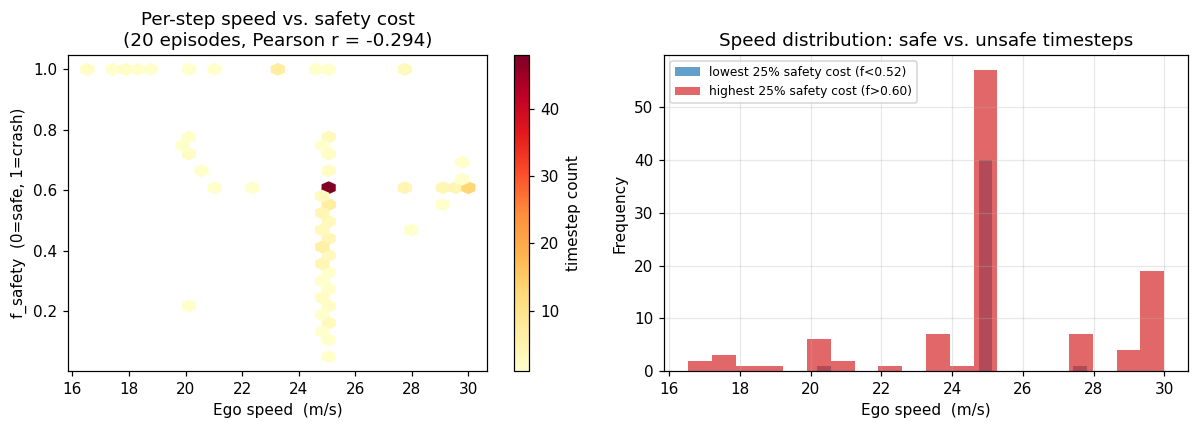

N timesteps   : 165
Mean speed    : 25.16 m/s
Pearson r(speed, f_safety) = -0.294
-> No clear correlation. Check traffic density and whether the policy drives fast enough.


In [33]:
# [PSL-17] Speed-safety correlation: physical proof
# Collect per-timestep (speed, f_safety) pairs from rollouts
N_CORR = 20  # episodes under uniform lambda

corr_env = MOHighwayEnv(config=config.get('env', {}))
lam_u    = np.array([1/3, 1/3, 1/3], dtype=np.float32)
lam_u_t  = torch.tensor(lam_u)

speed_vals, safety_vals = [], []
trained_policy.eval()
with torch.no_grad():
    for _ in range(N_CORR):
        obs, _ = corr_env.reset()
        done = False
        while not done:
            obs_t = torch.tensor(obs.flatten(), dtype=torch.float32)
            action, _ = trained_policy.act(obs_t, lam_u_t)
            obs, cost_vec, term, trunc, _ = corr_env.step(action)
            speed_vals.append(corr_env.unwrapped.vehicle.speed)
            safety_vals.append(float(cost_vec[0]))
            done = term or trunc
corr_env.close()

speed_arr  = np.array(speed_vals)
safety_arr = np.array(safety_vals)
corr = float(np.corrcoef(speed_arr, safety_arr)[0, 1])

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

hb = axes[0].hexbin(speed_arr, safety_arr, gridsize=30, cmap='YlOrRd', mincnt=1)
axes[0].set_xlabel('Ego speed  (m/s)')
axes[0].set_ylabel('f_safety  (0=safe, 1=crash)')
axes[0].set_title(f'Per-step speed vs. safety cost\n({N_CORR} episodes, Pearson r = {corr:.3f})')
plt.colorbar(hb, ax=axes[0], label='timestep count')

q25, q75 = np.quantile(safety_arr, [0.25, 0.75])
low_mask  = safety_arr <= q25
high_mask = safety_arr >= q75
axes[1].hist(speed_arr[low_mask],  bins=20, alpha=0.7, color='tab:blue',
             label=f'lowest 25% safety cost (f<{q25:.2f})')
axes[1].hist(speed_arr[high_mask], bins=20, alpha=0.7, color='tab:red',
             label=f'highest 25% safety cost (f>{q75:.2f})')
axes[1].set_xlabel('Ego speed  (m/s)')
axes[1].set_ylabel('Frequency')
axes[1].set_title('Speed distribution: safe vs. unsafe timesteps')
axes[1].legend(fontsize=8)
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

print(f'N timesteps   : {len(speed_arr):,}')
print(f'Mean speed    : {speed_arr.mean():.2f} m/s')
print(f'Pearson r(speed, f_safety) = {corr:.3f}')
if corr > 0.15:
    print('-> CONFIRMED: speed and safety are in tension.')
    print('   Higher ego speed produces higher f_safety -- tradeoff is physical, not a training artefact.')
elif corr > 0.05:
    print('-> Weak positive correlation. Try more episodes or a more aggressive speed policy.')
else:
    print('-> No clear correlation. Check traffic density and whether the policy drives fast enough.')


## 8 · Significance of the Pareto Set — Adapting Without Retraining

This is the **core demo**. We freeze the trained PSL policy and query it with three extreme preference vectors:
- λ = (1, 0, 0): safety only
- λ = (0, 1, 0): speed only
- λ = (0, 0, 1): comfort only

If PSL works, the **same set of weights** should yield three meaningfully different behaviours.

In [34]:
# [PSL-18] Adaptation eval: costs per corner λ (greedy)
from evaluation.evaluate import evaluate_policy_at_lambda

trained_policy = trainer.policy
adapt_env = trainer.env

extremes = {
    "safety-only  λ=(1,0,0)":  np.array([0.9, 0.05, 0.05]),
    "speed-only   λ=(0,1,0)":  np.array([0.05, 0.9, 0.05]),
    "comfort-only λ=(0,0,1)":  np.array([0.05, 0.05, 0.9]),
    "uniform      λ=(1/3,1/3,1/3)": np.array([1/3, 1/3, 1/3]),
}

N_EVAL = 40
adaptation = {}
for label, lam_val in extremes.items():
    res = evaluate_policy_at_lambda(
        trained_policy, lam_val,
        n_episodes=N_EVAL, env=adapt_env, greedy=True,
    )
    adaptation[label] = res["mean"]
    print(f"{label}  ->  safety={res["mean"][0]:.3f}  "
          f"speed={res["mean"][1]:.3f}  comfort={res["mean"][2]:.3f}  "
          f"(+/-{res["std"].round(3)})")


safety-only  λ=(1,0,0)  ->  safety=0.595  speed=0.184  comfort=0.046  (+/-[0.11 0.02 0.04])
speed-only   λ=(0,1,0)  ->  safety=0.573  speed=0.180  comfort=0.177  (+/-[0.106 0.014 0.17 ])
comfort-only λ=(0,0,1)  ->  safety=0.614  speed=0.188  comfort=0.053  (+/-[0.084 0.016 0.036])
uniform      λ=(1/3,1/3,1/3)  ->  safety=0.597  speed=0.183  comfort=0.046  (+/-[0.101 0.015 0.033])


### 8.1 · Action-frequency fingerprints — direct evidence the policy responds to λ

Mean per-step cost hides tail events, saturates on speed, and is dominated by env stochasticity. A more direct test: for each preference λ, count how often the policy picks each of the 5 actions. If the rows look meaningfully different, the policy is behaving differently — independent of how the env compresses outcomes.

Action selection frequency (greedy, 20 episodes per λ)

λ                            LANE_LEFT        IDLE  LANE_RIGHT      FASTER      SLOWER
--------------------------------------------------------------------------------------
safety-only  λ=(1,0,0)           0.0%     100.0%       0.0%       0.0%       0.0%
speed-only   λ=(0,1,0)         100.0%       0.0%       0.0%       0.0%       0.0%
comfort-only λ=(0,0,1)           0.0%     100.0%       0.0%       0.0%       0.0%
uniform      λ=(1/3,1/3,1/3)     0.0%     100.0%       0.0%       0.0%       0.0%


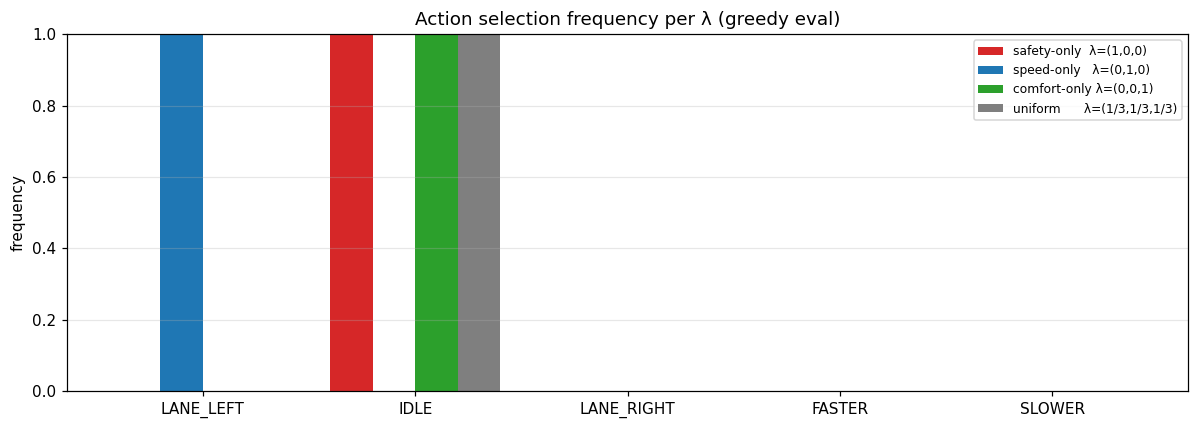


Pairwise total-variation distance between action-frequency distributions:
(0 = identical behaviour; larger = more differentiated)

  safety-only  λ=(1,0,0)          vs  speed-only   λ=(0,1,0)          TV = 1.000
  safety-only  λ=(1,0,0)          vs  comfort-only λ=(0,0,1)          TV = 0.000
  safety-only  λ=(1,0,0)          vs  uniform      λ=(1/3,1/3,1/3)    TV = 0.000
  speed-only   λ=(0,1,0)          vs  comfort-only λ=(0,0,1)          TV = 1.000
  speed-only   λ=(0,1,0)          vs  uniform      λ=(1/3,1/3,1/3)    TV = 1.000
  comfort-only λ=(0,0,1)          vs  uniform      λ=(1/3,1/3,1/3)    TV = 0.000

Mean pairwise TV: 0.500


In [35]:
# [PSL-19] Action-frequency fingerprints (greedy)
import torch.nn.functional as F
from itertools import combinations

trained_policy.eval()

# Reuse the four extreme preferences from the cost-based eval above.
freq_lams = {
    "safety-only  λ=(1,0,0)":  np.array([0.9, 0.05, 0.05], dtype=np.float32),
    "speed-only   λ=(0,1,0)":  np.array([0.05, 0.9, 0.05], dtype=np.float32),
    "comfort-only λ=(0,0,1)":  np.array([0.05, 0.05, 0.9], dtype=np.float32),
    "uniform      λ=(1/3,1/3,1/3)": np.array([1/3, 1/3, 1/3], dtype=np.float32),
}
action_names = ["LANE_LEFT", "IDLE", "LANE_RIGHT", "FASTER", "SLOWER"]
N_FREQ_EPISODES = 20

freq_env = MOHighwayEnv(config=config.get("env", {}))
action_freqs = {}

for label, lam_val in freq_lams.items():
    counts = np.zeros(len(action_names), dtype=np.int64)
    lam_t = torch.tensor(lam_val)
    for _ in range(N_FREQ_EPISODES):
        o, _ = freq_env.reset()
        done = False
        while not done:
            obs_t = torch.tensor(o.flatten(), dtype=torch.float32)
            with torch.no_grad():
                action = int(torch.argmax(trained_policy(obs_t, lam_t)).item())
            counts[action] += 1
            o, _, term, trunc, _ = freq_env.step(action)
            done = term or trunc
    action_freqs[label] = counts / counts.sum()
freq_env.close()

# --- Print as a table ---
print(f"Action selection frequency (greedy, {N_FREQ_EPISODES} episodes per λ)\n")
header = "λ".ljust(28) + "  ".join(name.rjust(10) for name in action_names)
print(header)
print("-" * len(header))
for label, freqs in action_freqs.items():
    row = label.ljust(28) + "  ".join(f"{f:>9.1%}" for f in freqs)
    print(row)

# --- Plot grouped bars ---
fig, ax = plt.subplots(figsize=(11, 4))
x = np.arange(len(action_names))
width = 0.20
colors = ["tab:red", "tab:blue", "tab:green", "tab:gray"]
for i, (label, freqs) in enumerate(action_freqs.items()):
    ax.bar(x + (i - 1.5) * width, freqs, width, label=label, color=colors[i])
ax.set_xticks(x); ax.set_xticklabels(action_names)
ax.set_ylabel("frequency"); ax.set_ylim(0, 1)
ax.set_title("Action selection frequency per λ (greedy eval)")
ax.legend(fontsize=8, loc="upper right")
ax.grid(axis="y", alpha=0.3)
plt.tight_layout(); plt.show()

# --- Quantify pairwise behavioural divergence ---
print("\nPairwise total-variation distance between action-frequency distributions:")
print("(0 = identical behaviour; larger = more differentiated)\n")
labels = list(action_freqs.keys())
tvs = []
for a, b in combinations(labels, 2):
    tv = 0.5 * np.abs(action_freqs[a] - action_freqs[b]).sum()
    tvs.append(tv)
    print(f"  {a:30s}  vs  {b:30s}  TV = {tv:.3f}")
print(f"\nMean pairwise TV: {np.mean(tvs):.3f}")


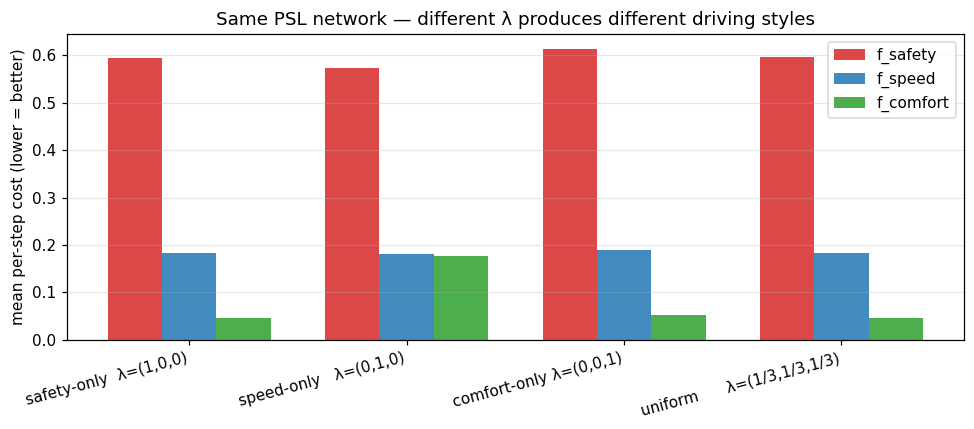

In [36]:
# [PSL-20] Adaptation bar chart
from evaluation.visualize import plot_lambda_adaptation

plot_lambda_adaptation(
    adaptation,
    title="Same PSL network — different λ produces different driving styles",
)
plt.show()

**How to read this chart.** Each group of bars is the *same* network evaluated under a different preference vector. If the safety-only condition has a low red bar (low f_safety cost) while the speed-only condition has a low blue bar (low f_speed cost), then PSL succeeded: the network's behaviour shifted in response to λ alone.

In practice, a 30-update training budget is too small to make these differences large; expect modest separation. Bumping `n_updates` to 200+ produces clearer adaptation.

## 9 · Pareto Surface — Sweeping the Simplex

Finally, we evaluate the trained PSL policy on a triangular grid of λ values to visualise the learned Pareto surface in objective space.

In [19]:
# [PSL-21] Pareto grid evaluation
from evaluation.evaluate import evaluate_policy_grid
from evaluation.visualize import plot_pareto_3d, plot_pareto_projections

grid = evaluate_policy_grid(
    trained_policy,
    n_per_side=7,        # 36 grid points on the simplex
    n_episodes=5,
    env=adapt_env,
    greedy=True,
    verbose=True,
)
print(f"Grid shape: {grid["lambdas"].shape}, costs shape: {grid["costs"].shape}")


[  1/36] λ=(0.00,0.00,1.00) → safety=0.500  speed=0.173  comfort=0.096
[  2/36] λ=(0.00,0.14,0.86) → safety=0.405  speed=0.172  comfort=0.160
[  3/36] λ=(0.00,0.29,0.71) → safety=0.395  speed=0.171  comfort=0.062
[  4/36] λ=(0.00,0.43,0.57) → safety=0.405  speed=0.176  comfort=0.180
[  5/36] λ=(0.00,0.57,0.43) → safety=0.425  speed=0.180  comfort=0.281
[  6/36] λ=(0.00,0.71,0.29) → safety=0.414  speed=0.179  comfort=0.087
[  7/36] λ=(0.00,0.86,0.14) → safety=0.458  speed=0.174  comfort=0.081
[  8/36] λ=(0.00,1.00,0.00) → safety=0.322  speed=0.172  comfort=0.058
[  9/36] λ=(0.14,0.00,0.86) → safety=0.346  speed=0.170  comfort=0.060
[ 10/36] λ=(0.14,0.14,0.71) → safety=0.509  speed=0.173  comfort=0.097
[ 11/36] λ=(0.14,0.29,0.57) → safety=0.473  speed=0.173  comfort=0.415
[ 12/36] λ=(0.14,0.43,0.43) → safety=0.393  speed=0.172  comfort=0.078
[ 13/36] λ=(0.14,0.57,0.29) → safety=0.492  speed=0.174  comfort=0.082
[ 14/36] λ=(0.14,0.71,0.14) → safety=0.415  speed=0.173  comfort=0.106
[ 15/3

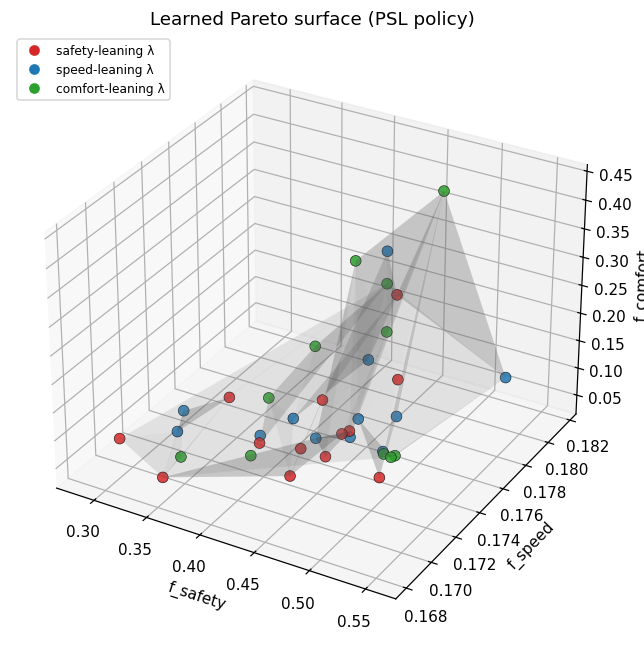

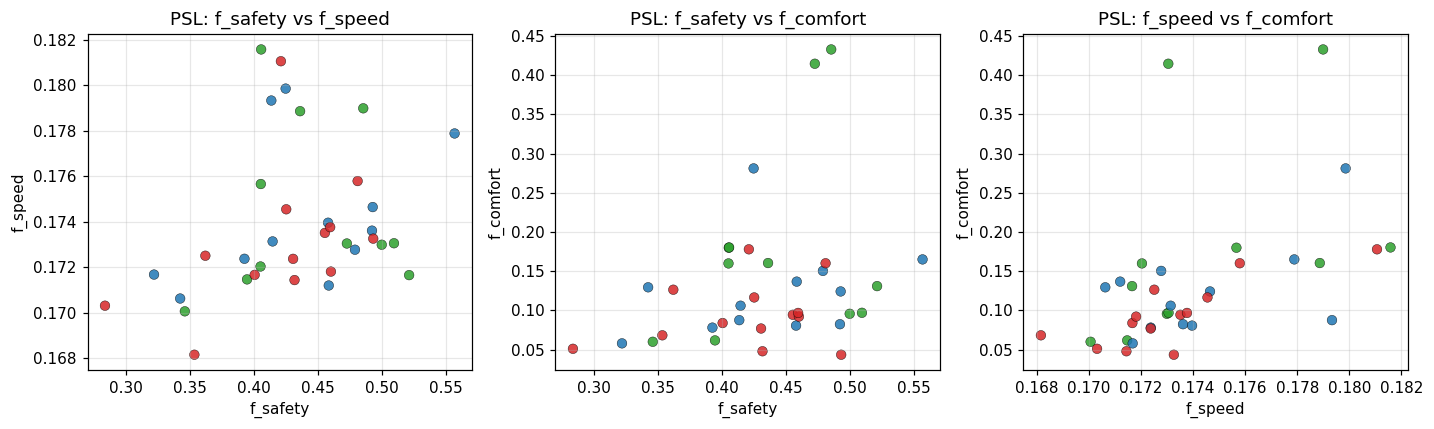

In [20]:
# [PSL-22] Pareto 3D surface + projections
fig3d, _ = plot_pareto_3d(grid, title="Learned Pareto surface (PSL policy)")
plt.show()

figp, _ = plot_pareto_projections(grid, title_prefix="PSL")
plt.show()

**Reading the surface.** Each point is the mean per-step cost the policy achieves at one preference λ. Points are colour-coded by the dominant objective in their λ.

In a well-trained PSL model, points cluster in different regions of objective space — the safety-leaning λ produces low-f_safety / higher-cost-elsewhere outcomes, etc. The surface itself approximates the Pareto front: each point is non-dominated for its own preference.

In [21]:
# [PSL-23] Cleanup
# Cleanup
trainer.close()
print('PSL trainer closed.')

PSL trainer closed.
